# Speech / Silence Segmentation using Simple Statistics

**Student:** Nguyen Hoang Hieu – Student ID 102240135


**Workflow:**
1. **Training Phase:** Load the training signals, split them into frames and compute STE, then label each frame using the `.lab` files. Estimate the normal distribution (μ, σ) of STE for the *Speech* and *Silence* classes, and find the optimal threshold **T** as the intersection point of the two normal distributions.
2. **Testing Phase:** Apply the threshold T to the test signals, post-process (remove silences shorter than 200 ms), extract the time boundaries, compare them with the ground truth boundaries (MAE, RMSE) and display comparative graphs.

In [7]:
import os
import wave
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

%matplotlib inline

## 1. Parameters & Configuration
Set up the fixed algorithm parameters and the data directories.

In [8]:
# Fixed parameters
FRAME_LEN_MS = 25       # Frame duration (ms)
FRAME_SHIFT_MS = 10     # Frame shift/step (ms)
MIN_SILENCE_MS = 200    # Minimum silence duration to preserve (ms)

# Data directories (auto-detected in the current or the parent directory)
BASE_DIR = next((d for d in ['.', '..'] if os.path.isdir(os.path.join(d, 'TinHieuHuanLuyen'))), '.')
TRAIN_DIR = os.path.join(BASE_DIR, 'TinHieuHuanLuyen')
TEST_DIR = os.path.join(BASE_DIR, 'TinHieuKiemThu')


## 2. Core Functions
Functions for file reading, feature extraction (STE, ZCR, F0), threshold calculation, post-processing, boundary extraction and error calculation.

In [9]:
def readAudio(path):
    """Get the data of an .wav file for further processes (normalized Signal, sample rate, time axis)"""
    with wave.open(path, 'rb') as WavFile:
        SampleRate = WavFile.getframerate()            #how many samples are there in an amount of time aka frequency
        SampleAmount = WavFile.getnframes()            #how many samples are there 
        RawData = WavFile.readframes(SampleAmount)    #raw strings of all samples in 16 bit format

        #read the raw string in 16 bit, as conventional .wav files are saved in 16 bit format
        #this is to ensure that numpy read the raw data correctly
        Signal = np.frombuffer(RawData, dtype=np.int16)

        #normalize the amp to range of -1 to 1
        MaxAmp = np.max(np.abs(Signal))
        if MaxAmp > 0:
            SignalNormalized = Signal / MaxAmp
        else:
            SignalNormalized = Signal                  #in case Signal file is empty so that it doesnt crash

        Duration = SampleAmount / SampleRate
        TimeAxis = np.linspace(0, Duration, num=SampleAmount)

        return SignalNormalized, SampleRate, TimeAxis

def read_lab_file(lab_path):
    """
    Purpose: Read a .lab file and extract the time stamps of each label.
    Input: lab_path (string) - Path to the .lab file
    Output: intervals (list) - List of tuples (start_time, end_time, label)
    """
    intervals = []
    with open(lab_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3 and parts[0] not in ['F0mean', 'F0std']:
                start, end, label = float(parts[0]), float(parts[1]), parts[2]
                intervals.append((start, end, label))
    return intervals

def get_frame_label(time_sec, intervals):
    """
    Purpose: Label a frame based on its time stamp compared with the .lab data.
    Input: time_sec (float), intervals (list)
    Output: int - 0 (Silence), 1 (Speech)
    """
    for start, end, label in intervals:
        if start <= time_sec <= end:
            return 0 if label == 'sil' else 1
    return 0

def extract_features(signal, fs):
    """
    Purpose: Split the signal into frames and compute the (normalized) STE and ZCR features.
    Input: signal (numpy array), fs (int)
    Output: ste, zcr, times (numpy arrays)
    """
    frame_len = int(fs * FRAME_LEN_MS / 1000)
    frame_shift = int(fs * FRAME_SHIFT_MS / 1000)
    num_frames = int(np.ceil(len(signal) / frame_shift))
    
    ste = np.zeros(num_frames)
    zcr = np.zeros(num_frames)
    times = np.zeros(num_frames)
    window = np.hamming(frame_len)
    
    # Iterate over each frame, apply the window and compute the features
    for i in range(num_frames):
        start_idx = i * frame_shift
        end_idx = min(start_idx + frame_len, len(signal))
        frame = signal[start_idx:end_idx]
        
        if len(frame) < frame_len:
            frame = np.pad(frame, (0, frame_len - len(frame)), 'constant')
            
        frame = frame * window
        ste[i] = np.sum(frame ** 2)
        zcr[i] = np.sum(np.abs(np.diff(np.sign(frame)))) / (2 * frame_len)
        times[i] = start_idx / fs
        
    if np.max(ste) > 0: ste = ste / np.max(ste)
    if np.max(zcr) > 0: zcr = zcr / np.max(zcr)
    
    return ste, zcr, times

def calculate_f0_autocorr(signal, fs):
    """
    Purpose: Extract F0 using the Autocorrelation method.
    Input: signal (numpy array), fs (int)
    Output: f0, t_f0 (numpy arrays)
    """
    frame_len = int(fs * FRAME_LEN_MS / 1000)
    frame_shift = int(fs * FRAME_SHIFT_MS / 1000)
    num_frames = int(np.ceil(len(signal) / frame_shift))
    
    f0 = np.zeros(num_frames)
    t_f0 = np.zeros(num_frames)
    min_lag = int(fs / 400)
    max_lag = int(fs / 70)
    
    # Compute the autocorrelation to find the period (peak of the autocorrelation function)
    for i in range(num_frames):
        start = i * frame_shift
        end = min(start + frame_len, len(signal))
        frame = signal[start:end]
        
        if len(frame) == frame_len:
            corr = np.correlate(frame, frame, mode='full')
            corr = corr[len(corr)//2:] 
            if len(corr) > max_lag:
                peak_idx = np.argmax(corr[min_lag:max_lag]) + min_lag
                f0[i] = fs / peak_idx
        t_f0[i] = start / fs
        
    f0 = np.where(f0 > 400, 0, f0)
    return f0, t_f0

def find_intersection(mu1, std1, mu2, std2):
    """
    Purpose: Find the classification threshold by solving for the intersection of 2 normal distributions.
    Input: Mean and standard deviation of the 2 classes (float)
    Output: Optimal threshold (float)
    """
    a = 1.0/(2*std1**2) - 1.0/(2*std2**2)
    b = mu2/(std2**2) - mu1/(std1**2)
    c = mu1**2 /(2*std1**2) - mu2**2 /(2*std2**2) - np.log(std2/std1)
    
    roots = np.roots([a, b, c])
    for root in roots:
        if min(mu1, mu2) <= root <= max(mu1, mu2):
            return root
    return roots[0]

def smooth_boundaries(flags, min_sil_frames):
    """
    Purpose: Remove spurious silences and speech segments that are too short (post-processing).
    Input: initial label flags (numpy array), minimum number of frames (int)
    Output: smoothed label flags (numpy array)
    """
    smoothed = flags.copy()
    
    # 1. Remove isolated speech frames (single 1s)
    for i in range(1, len(smoothed) - 1):
        if smoothed[i-1] == 0 and smoothed[i] == 1 and smoothed[i+1] == 0:
            smoothed[i] = 0
            
    # 2. Merge silence regions (0) shorter than 200ms into speech (1)
    zero_count = 0
    zero_start = -1
    for i in range(len(smoothed)):
        if smoothed[i] == 0:
            if zero_count == 0: zero_start = i
            zero_count += 1
        else:
            if 0 < zero_count < min_sil_frames:
                smoothed[zero_start:i] = 1
            zero_count = 0
            
    if 0 < zero_count < min_sil_frames:
        smoothed[zero_start:len(smoothed)] = 1
        
    return smoothed

def get_true_speech_boundaries(intervals):
    """
    Purpose: Merge 'v' and 'uv' into continuous speech segments to get the ground truth boundaries (red).
    Input: intervals (list)
    Output: List of speech start/end time stamps (list)
    """
    bounds = []
    is_speech = False
    for start, end, label in intervals:
        if label != 'sil':
            if not is_speech:
                bounds.append(start)  # Speech starts
                is_speech = True
        else:
            if is_speech:
                bounds.append(start)  # Speech ends
                is_speech = False
    if is_speech:
        bounds.append(intervals[-1][1])
    return bounds

def get_pred_boundaries(flags, times):
    """
    Purpose: Get the time stamps where the state changes in the label flags (predicted boundaries - blue).
    Input: flags (numpy array of 0/1), times (numpy array)
    Output: List of speech start/end time stamps (list)
    """
    diff = np.diff(np.insert(flags, 0, 0))
    pred_bounds = [times[i] for i, d in enumerate(diff) if d == 1 or d == -1]
    if flags[-1] == 1: pred_bounds.append(times[-1])
    return pred_bounds

def calculate_errors(true_bounds, pred_bounds):
    """
    Purpose: Compute MAE and RMSE (in ms) using nearest-neighbor boundary matching.
    Input: true_bounds (red boundaries), pred_bounds (blue boundaries)
    Output: mae, rmse (float) in milliseconds
    """
    if not true_bounds or not pred_bounds:
        return 0.0, 0.0
        
    errors = []
    for tb in true_bounds:
        # Find the predicted boundary (blue) closest to the current ground truth boundary (red)
        closest_pb = min(pred_bounds, key=lambda pb: abs(pb - tb))
        error_ms = abs(tb - closest_pb) * 1000 # Convert seconds to ms
        errors.append(error_ms)
        
    errors_arr = np.array(errors)
    mae = np.mean(errors_arr)                      # Mean Absolute Error
    rmse = np.sqrt(np.mean(errors_arr ** 2))       # Root Mean Squared Error
    
    return mae, rmse

def format_segments(bounds, is_true):
    """
    Purpose: Group the list of boundaries into [start, end] pairs for printing.
    """
    segs = []
    decimals = 2 if is_true else 3
    for i in range(0, len(bounds), 2):
        s = round(float(bounds[i]), decimals)
        e = round(float(bounds[i+1]), decimals) if i+1 < len(bounds) else s
        segs.append([s, e])
    return segs

## 3. Training Module
Compute STE for all training signals, group the frames by label (*Speech* / *Silence*), estimate the normal distribution of each class and find the threshold **T** at the intersection of the two distributions.

In [10]:
def train(train_dir=TRAIN_DIR):
    """
    Purpose: Training - estimate the STE normal distribution of the 2 classes and the optimal threshold.
    Output: dict containing the threshold, distribution parameters and STE data of the 2 classes
    """
    files = sorted(f for f in os.listdir(train_dir) if f.endswith('.wav'))
    if not files:
        print(f"Warning: No training files found in '{train_dir}'!")
        return None

    speech_ste, silence_ste = [], []
    for file in files:
        wav_path = os.path.join(train_dir, file)
        lab_path = os.path.join(train_dir, file.replace('.wav', '.lab'))

        signal, fs, t_sig = readAudio(wav_path)
        intervals = read_lab_file(lab_path)
        ste, _, times = extract_features(signal, fs)

        for i, t in enumerate(times):
            label = get_frame_label(t, intervals)
            if label == 1: speech_ste.append(ste[i])
            else: silence_ste.append(ste[i])
        print(f"  Processed: {file}")

    speech_ste, silence_ste = np.array(speech_ste), np.array(silence_ste)
    mu_sp, std_sp = np.mean(speech_ste), np.std(speech_ste)
    mu_sil, std_sil = np.mean(silence_ste), np.std(silence_ste)
    threshold = find_intersection(mu_sil, std_sil, mu_sp, std_sp)

    print(f"\n=> Number of frames: Speech = {len(speech_ste)}, Silence = {len(silence_ste)}")
    print(f"=> Normal distributions: Speech (μ={mu_sp:.4f}, σ={std_sp:.4f}), Silence (μ={mu_sil:.4f}, σ={std_sil:.4f})")
    print(f"=> Optimal STE threshold: {threshold:.4f}")
    print(f"\n[SHARED THRESHOLD] T1 (STE) = {threshold:.5f} | (Based on normal distributions)")

    return {
        'threshold': threshold,
        'mu_sp': mu_sp, 'std_sp': std_sp,
        'mu_sil': mu_sil, 'std_sil': std_sil,
        'speech_ste': speech_ste, 'silence_ste': silence_ste,
    }

def gaussian_pdf(x, mu, std):
    return np.exp(-(x - mu) ** 2 / (2 * std ** 2)) / (std * np.sqrt(2 * np.pi))

def plot_training_distribution(model):
    """
    Purpose: Plot the STE histogram of the 2 classes, the estimated normal distributions and the threshold.
    """
    T = model['threshold']

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
    fig.suptitle('Training: STE Distribution of Speech and Silence', fontsize=13)

    # (a) Histogram of the number of frames per class
    bins = np.linspace(0, 1, 51)
    ax[0].hist(model['silence_ste'], bins=bins, alpha=0.6, color='gray', label=f"Silence ({len(model['silence_ste'])} frames)")
    ax[0].hist(model['speech_ste'], bins=bins, alpha=0.6, color='tab:orange', label=f"Speech ({len(model['speech_ste'])} frames)")
    ax[0].axvline(T, color='purple', linestyle='--', linewidth=2, label=f'Threshold T = {T:.4f}')
    ax[0].set_xlim(0, 1)
    ax[0].set_title('STE Histogram by Label')
    ax[0].set_xlabel('STE (normalized)')
    ax[0].set_ylabel('Number of frames')
    ax[0].legend(fontsize=9)
    ax[0].grid(True, alpha=0.3)

    # (b) Estimated normal distributions and their intersection (threshold)
    xmax = max(0.25, 4 * T)
    xx = np.linspace(0, xmax, 2000)
    pdf_sil = gaussian_pdf(xx, model['mu_sil'], model['std_sil'])
    pdf_sp = gaussian_pdf(xx, model['mu_sp'], model['std_sp'])
    ax[1].plot(xx, pdf_sil, color='black', linewidth=2,
               label=f"Silence: N(μ={model['mu_sil']:.4f}, σ={model['std_sil']:.4f})")
    ax[1].plot(xx, pdf_sp, color='red', linewidth=2,
               label=f"Speech: N(μ={model['mu_sp']:.4f}, σ={model['std_sp']:.4f})")
    ax[1].fill_between(xx, pdf_sil, where=xx <= T, color='gray', alpha=0.2)
    ax[1].fill_between(xx, pdf_sp, where=xx >= T, color='tab:orange', alpha=0.2)
    yT = gaussian_pdf(T, model['mu_sp'], model['std_sp'])
    ax[1].axvline(T, color='purple', linestyle='--', linewidth=2, label=f'Threshold T = {T:.4f} (intersection)')
    ax[1].plot(T, yT, 'o', color='purple', markersize=8)
    ax[1].set_xlim(0, xmax)
    ax[1].set_ylim(0, 1.1 * pdf_sil.max())
    ax[1].set_title('Estimated Normal Distributions (zoomed around threshold)')
    ax[1].set_xlabel('STE (normalized)')
    ax[1].set_ylabel('Probability density')
    ax[1].legend(fontsize=9)
    ax[1].grid(True, alpha=0.3)
    plt.show()

## 4. Testing Module
Apply the global threshold to the test signals, compute MAE / RMSE and plot the boundary comparison figures.

In [11]:
def plot_results(signal, fs, t_sig, times, ste, zcr, true_bounds, pred_bounds, wav_name, threshold, mae, rmse):
    """
    Purpose: Visualize the intermediate features, the time boundaries (ground truth vs predicted) and F0.
    """
    f0, t_f0 = calculate_f0_autocorr(signal, fs)

    fig = plt.figure(figsize=(14, 6.5))
    plt.suptitle(f'Result of {wav_name} | MAE: {mae:.1f}ms - RMSE: {rmse:.1f}ms', fontsize=13)

    # ============ LAYER 1: INTERMEDIATE FEATURES ============
    plt.subplot(2, 1, 1)
    plt.plot(t_sig, signal, label='Normalized Signal', color='lightgray')
    plt.plot(times, ste, label='STE', color='blue', linewidth=1.5)
    plt.plot(times, zcr, label='ZCR', color='green', linewidth=1.5)
    plt.axhline(y=threshold, color='purple', linestyle='--', linewidth=1.5, alpha=0.8, label=f'Threshold ({threshold:.3f})')
    plt.title('Intermediate Features')
    plt.ylabel('Amplitude')
    plt.xlim(0, t_sig[-1])
    plt.legend(loc='upper right')
    plt.grid(True)

    # ============ LAYER 2: BOUNDARY AND F0 COMPARISON ============
    plt.subplot(2, 1, 2)
    plt.plot(t_sig, signal, label='Signal', color='lightgray')

    f0_plot = np.where(f0 > 0, f0, np.nan)
    f0_norm = (f0_plot - np.nanmin(f0_plot)) / (np.nanmax(f0_plot) - np.nanmin(f0_plot)) * np.max(np.abs(signal))
    plt.plot(t_f0, f0_norm, 'r.', label='F0 Contour', markersize=3)

    # Plot ground truth boundaries (RED)
    for tb in true_bounds:
        plt.axvline(x=tb, color='red', linestyle='-', linewidth=2, alpha=0.7)

    # Plot predicted boundaries (BLUE)
    for pb in pred_bounds:
        plt.axvline(x=pb, color='blue', linestyle='-', linewidth=2)

    plt.title('Time Boundary and F0 Comparison')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude / F0 (Scaled)')
    plt.xlim(0, t_sig[-1])

    red_line = mlines.Line2D([], [], color='red', linestyle='-', label='Ground truth (Red)')
    blue_line = mlines.Line2D([], [], color='blue', linestyle='-', label='Predicted (Blue)')
    f0_dot = mlines.Line2D([], [], color='red', marker='.', linestyle='None', label='F0')
    plt.legend(handles=[red_line, blue_line, f0_dot], loc='upper right')

    plt.tight_layout()
    plt.show()

def test(model, test_dir=TEST_DIR):
    """
    Purpose: Test the threshold on the test set, print the results and plot a figure for each file.
    """
    threshold = model['threshold']
    min_sil_frames = int(MIN_SILENCE_MS / FRAME_SHIFT_MS)
    files = sorted(f for f in os.listdir(test_dir) if f.endswith('.wav'))
    table_data = []

    for file in files:
        wav_path = os.path.join(test_dir, file)
        lab_path = os.path.join(test_dir, file.replace('.wav', '.lab'))

        signal, fs, t_sig = readAudio(wav_path)
        intervals = read_lab_file(lab_path)
        ste, zcr, times = extract_features(signal, fs)

        flags = np.where(ste > threshold, 1, 0)
        smoothed_flags = smooth_boundaries(flags, min_sil_frames)

        true_bounds = get_true_speech_boundaries(intervals)
        pred_bounds = get_pred_boundaries(smoothed_flags, times)
        mae, rmse = calculate_errors(true_bounds, pred_bounds)

        table_data.append({
            'file': file,
            'true_count': len(true_bounds),
            'pred_count': len(pred_bounds),
            'mae': mae,
            'rmse': rmse
        })

        print(f"{file}")
        print(f"  ground truth : {format_segments(true_bounds, is_true=True)}")
        print(f"  algorithm    : {format_segments(pred_bounds, is_true=False)}")

        plot_results(signal, fs, t_sig, times, ste, zcr, true_bounds, pred_bounds, file, threshold, mae, rmse)

    # Summary table of the test results
    print("\n[TEST RESULTS]")
    print(f"{'File':<15} {'#GT bounds':>11} {'#Alg bounds':>12} {'MAE(ms)':>9} {'RMSE(ms)':>9}")

    total_mae, total_rmse = 0, 0
    for row in table_data:
        print(f"{row['file']:<15} {row['true_count']:>11} {row['pred_count']:>12} {row['mae']:>9.2f} {row['rmse']:>9.2f}")
        total_mae += row['mae']
        total_rmse += row['rmse']

    if table_data:
        print(f"{'AVERAGE':<15} {'':>11} {'':>12} {total_mae/len(table_data):>9.2f} {total_rmse/len(table_data):>9.2f}")

    return table_data

## 5. Main Execution
Run the training module first, then proceed immediately to testing with the obtained threshold.

--- STARTING TRAINING PHASE ---
  Processed: phone_F1.wav
  Processed: phone_M1.wav
  Processed: studio_F1.wav
  Processed: studio_M1.wav

=> Number of frames: Speech = 794, Silence = 507
=> Normal distributions: Speech (μ=0.1697, σ=0.2071), Silence (μ=0.0014, σ=0.0235)
=> Optimal STE threshold: 0.0522

[SHARED THRESHOLD] T1 (STE) = 0.05221 | (Based on normal distributions)

Training STE distribution:


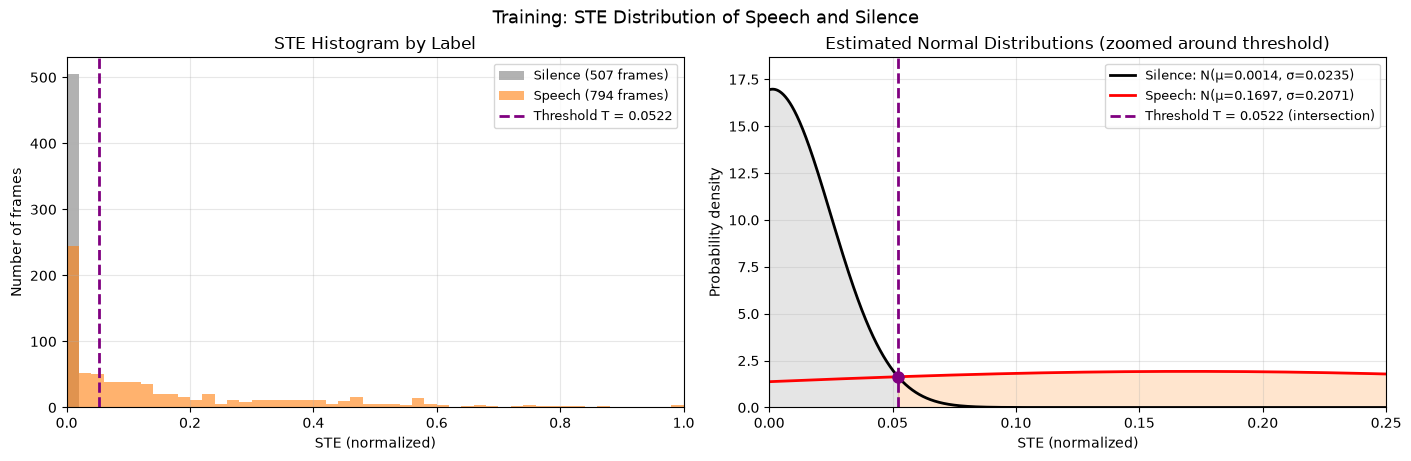


--- STARTING TESTING PHASE ---
phone_F2.wav
  ground truth : [[1.02, 4.04]]
  algorithm    : [[1.09, 2.49], [2.8, 3.44], [3.67, 3.99]]


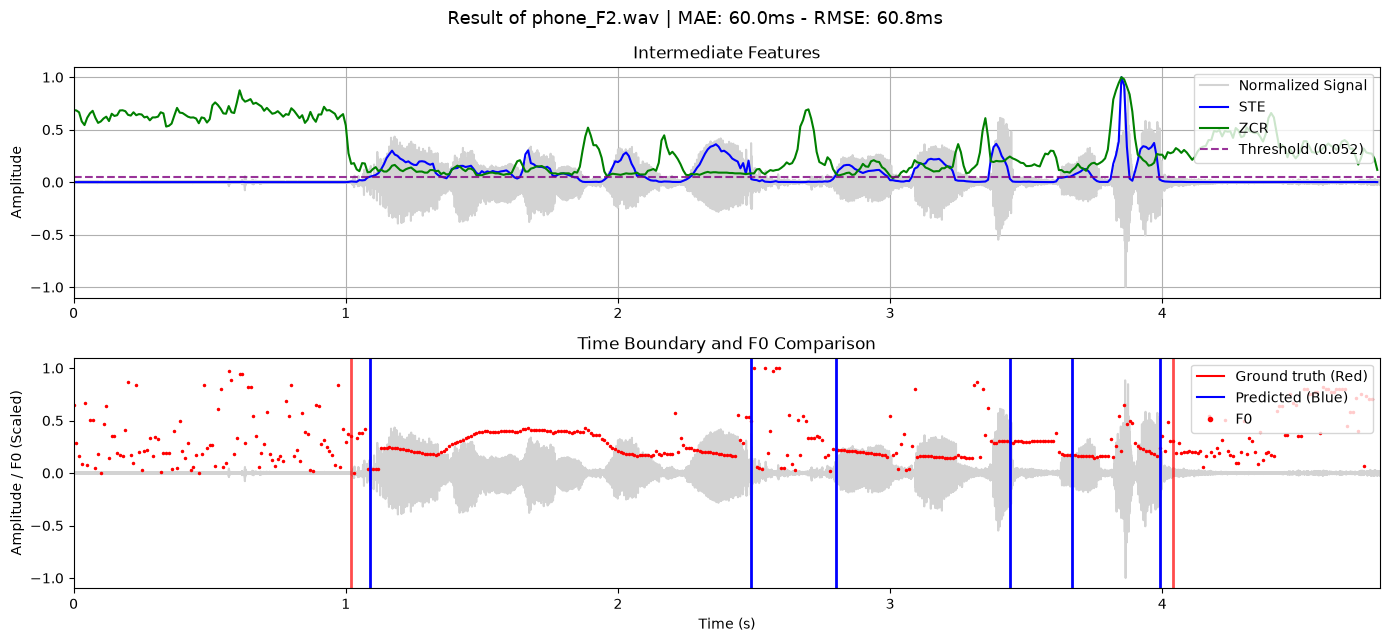

phone_M2.wav
  ground truth : [[0.53, 2.52]]
  algorithm    : [[0.53, 1.46], [1.67, 2.49]]


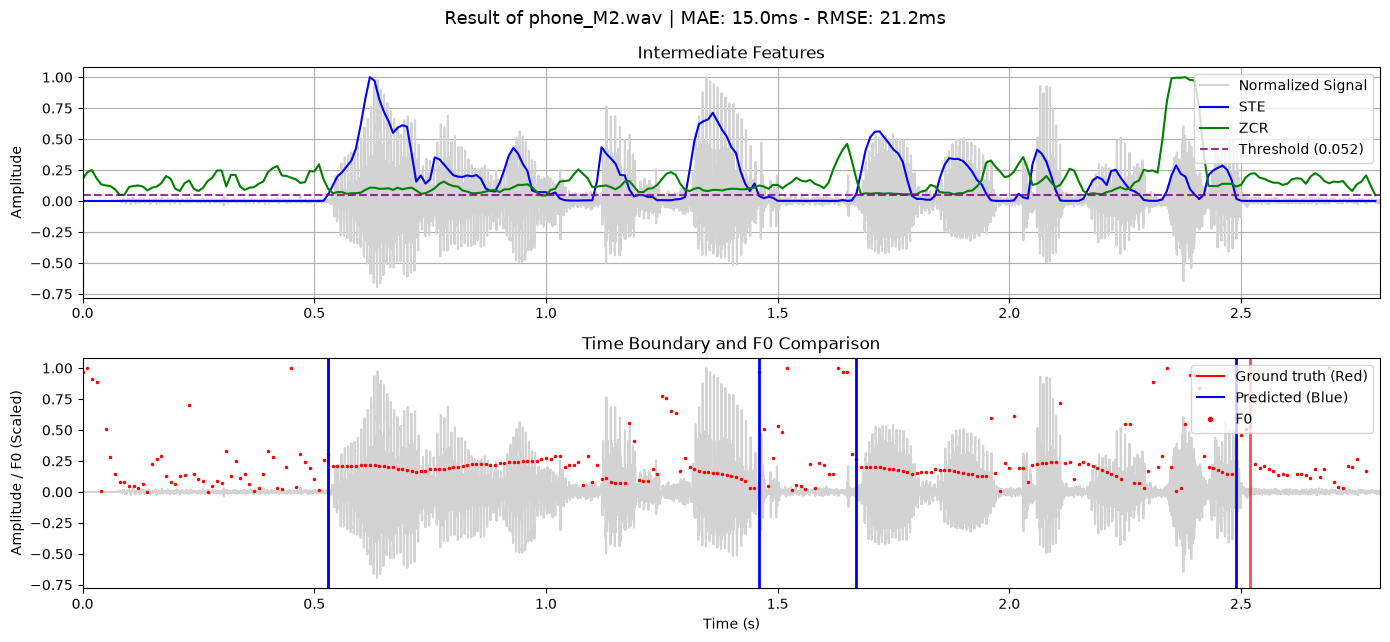

studio_F2.wav
  ground truth : [[0.77, 2.37]]
  algorithm    : [[0.77, 2.29]]


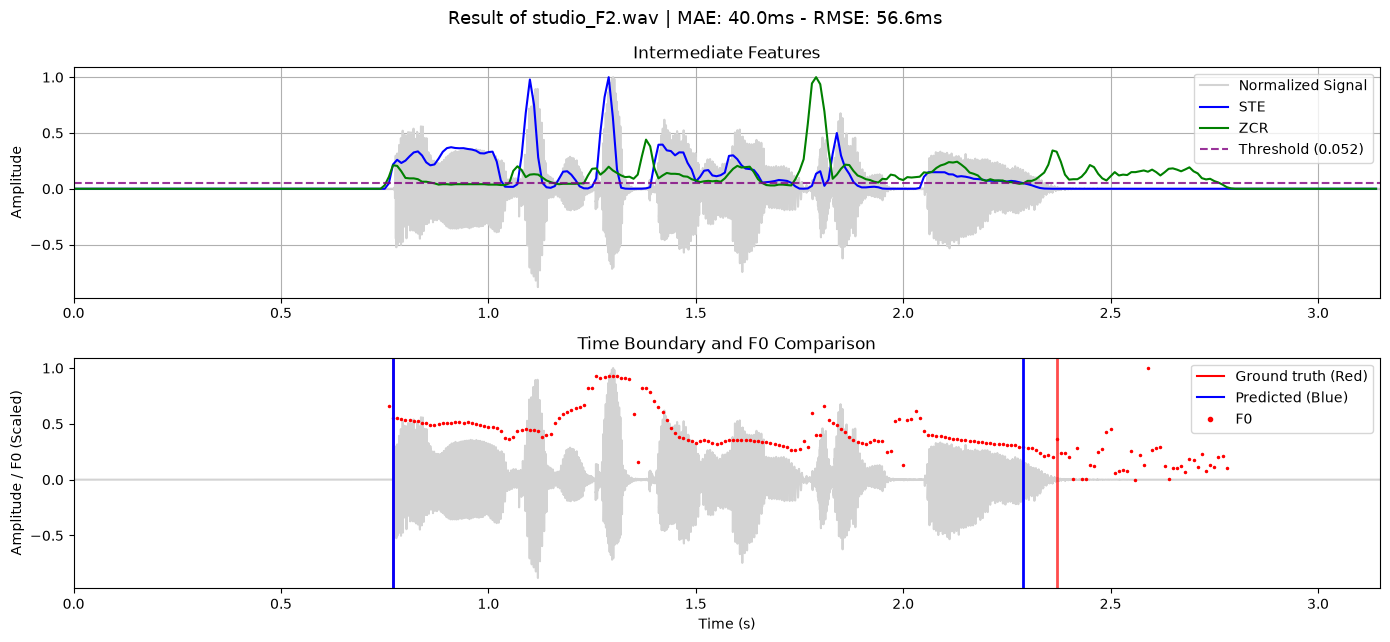

studio_M2.wav
  ground truth : [[0.45, 1.93]]
  algorithm    : [[0.47, 1.88]]


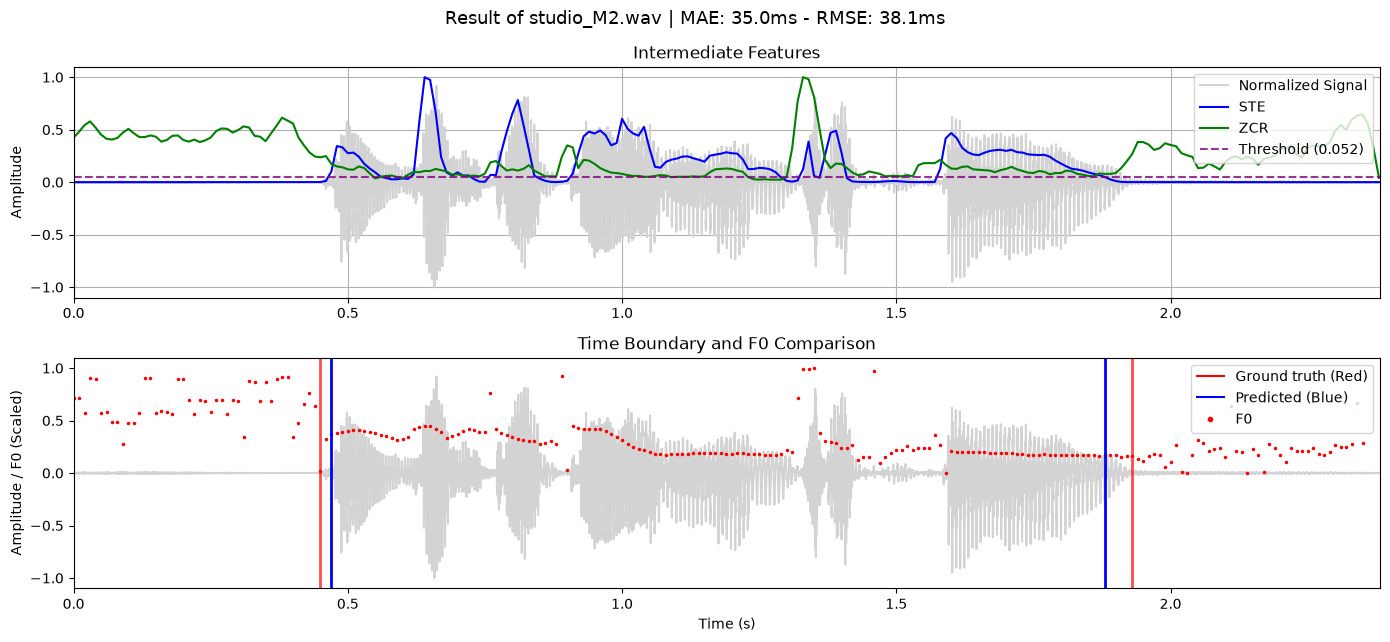


[TEST RESULTS]
File             #GT bounds  #Alg bounds   MAE(ms)  RMSE(ms)
phone_F2.wav              2            6     60.00     60.83
phone_M2.wav              2            4     15.00     21.21
studio_F2.wav             2            2     40.00     56.57
studio_M2.wav             2            2     35.00     38.08
AVERAGE                                      37.50     44.17


In [12]:
def main():
    print("--- STARTING TRAINING PHASE ---")
    model = train()

    if model:
        print("\nTraining STE distribution:")
        plot_training_distribution(model)

        print("\n--- STARTING TESTING PHASE ---")
        test(model)
    else:
        print("Training failed. Ensure the 'TinHieuHuanLuyen' folder exists and contains valid .wav/.lab files.")

if __name__ == "__main__":
    main()